In [1]:
import numpy as np
import matplotlib.pyplot as plt

# step1 : load data
data = np.load("mnist.npz")
Xtr_full, ytr_full = data["x_train"], data["y_train"]
Xte_full, yte_full = data["x_test"],  data["y_test"]
print("Train raw:", Xtr_full.shape, "Test raw:", Xte_full.shape)



Train raw: (60000, 28, 28) Test raw: (10000, 28, 28)


In [2]:
# step2 : filter 4 & 9
tr_mask = (ytr_full == 4) | (ytr_full == 9)
te_mask = (yte_full == 4) | (yte_full == 9)
Xtr_f, ytr_f = Xtr_full[tr_mask], ytr_full[tr_mask]
Xte_f, yte_f = Xte_full[te_mask], yte_full[te_mask]
print("Filtered train:", Xtr_f.shape, "Filtered test:", Xte_f.shape)



Filtered train: (11791, 28, 28) Filtered test: (1991, 28, 28)


In [3]:
# step3 : relabel -1/+1
ytr_f = np.where(ytr_f == 4, -1.0, 1.0)
yte_f = np.where(yte_f == 4, -1.0, 1.0)
print("Train label unique:", np.unique(ytr_f, return_counts=True))
print("Test  label unique:", np.unique(yte_f, return_counts=True))



Train label unique: (array([-1.,  1.]), array([5842, 5949]))
Test  label unique: (array([-1.,  1.]), array([ 982, 1009]))


In [4]:
# step4 : flatten & normalize
Xtr_f = Xtr_f.reshape(len(Xtr_f), -1) / 255.0
Xte_f = Xte_f.reshape(len(Xte_f), -1) / 255.0
print("Flattened train:", Xtr_f.shape, "Flattened test:", Xte_f.shape)



Flattened train: (11791, 784) Flattened test: (1991, 784)


In [5]:
# step5 : split val (1000 per class)
def split_val(X, y, n=1000):
    idx_n1 = np.where(y == -1)[0]
    idx_p1 = np.where(y ==  1)[0]
    val_idx = np.concatenate([idx_n1[:n], idx_p1[:n]])
    tr_idx  = np.concatenate([idx_n1[n:], idx_p1[n:]])
    return X[tr_idx], y[tr_idx], X[val_idx], y[val_idx]

Xtr, ytr, Xval, yval = split_val(Xtr_f, ytr_f)
print("Train:", Xtr.shape, ytr.shape,
      "Val:", Xval.shape, yval.shape)


Train: (9791, 784) (9791,) Val: (2000, 784) (2000,)


In [6]:

# step6 : PCA on train only
def fit_pca(X, k=5):
    mu   = X.mean(axis=0)
    Xc   = X - mu
    C    = Xc.T @ Xc / (len(X) - 1)
    vals, vecs = np.linalg.eigh(C)
    idx  = np.argsort(vals)[::-1]
    W    = vecs[:, idx[:k]]
    return mu, W

def apply_pca(X, mu, W):
    return (X - mu) @ W

mu_pca, W_pca = fit_pca(Xtr, k=5)
Xtr_p  = apply_pca(Xtr,  mu_pca, W_pca)
Xval_p = apply_pca(Xval, mu_pca, W_pca)
Xte_p  = apply_pca(Xte_f, mu_pca, W_pca)
print("PCA train:", Xtr_p.shape,
      "PCA val:",  Xval_p.shape,
      "PCA test:", Xte_p.shape)


PCA train: (9791, 5) PCA val: (2000, 5) PCA test: (1991, 5)


In [7]:

# step7 : stump for SSR
def best_stump_ssr(X, y, rng, n_thresh=1000):
    n, d  = X.shape
    best  = dict(ssr=np.inf, feat=0, thr=0.0, l_val=0.0, r_val=0.0)
    for j in range(d):
        vals  = np.unique(X[:, j])
        if len(vals) < 2:
            continue
        cands = (vals[:-1] + vals[1:]) / 2.0
        if len(cands) > n_thresh:
            cands = rng.choice(cands, n_thresh, replace=False)
        for thr in cands:
            lm = X[:, j] <= thr
            rm = ~lm
            if lm.sum() == 0 or rm.sum() == 0:
                continue
            lv   = y[lm].mean()
            rv   = y[rm].mean()
            ssr  = ((y[lm] - lv)**2).sum() + ((y[rm] - rv)**2).sum()
            if ssr < best["ssr"]:
                best = dict(ssr=ssr, feat=j, thr=thr,
                            l_val=lv, r_val=rv)
    return best

def stump_predict_ssr(X, stump):
    j, thr = stump["feat"], stump["thr"]
    pred   = np.where(X[:, j] <= thr, stump["l_val"], stump["r_val"])
    return pred


In [8]:

# step8 : gradient boost loop (absolute loss → neg gradient = sign of residue)
def gb_run(Xtr_p, ytr, Xval_p, yval, Xte_p, yte_f, eta=0.01, T=300):
    rng      = np.random.default_rng(42)
    n        = len(Xtr_p)
    F_tr     = np.zeros(n)
    F_val    = np.zeros(len(Xval_p))
    F_te     = np.zeros(len(Xte_p))
    stumps   = []
    tr_mses  = []
    val_mses = []

    for t in range(T):
        # step8a : negative gradient (absolute loss)
        pseudo_r = np.sign(ytr - F_tr)

        # step8b : fit stump on pseudo residuals
        s      = best_stump_ssr(Xtr_p, pseudo_r, rng)
        h_tr   = stump_predict_ssr(Xtr_p, s)
        h_val  = stump_predict_ssr(Xval_p, s)
        h_te   = stump_predict_ssr(Xte_p, s)

        # step8c : update predictions
        F_tr  += eta * h_tr
        F_val += eta * h_val
        F_te  += eta * h_te
        stumps.append(s)

        tr_mse  = np.mean((ytr  - F_tr) ** 2)
        val_mse = np.mean((yval - F_val) ** 2)
        tr_mses.append(tr_mse)
        val_mses.append(val_mse)

        if (t + 1) % 50 == 0:
            print(f"  eta={eta} iter {t+1:3d} | "
                  f"tr_mse={tr_mse:.4f} val_mse={val_mse:.4f}")

    best_t   = int(np.argmin(val_mses))
    # recompute test at best_t
    F_te_b = np.zeros(len(Xte_p))
    for t in range(best_t + 1):
        F_te_b += eta * stump_predict_ssr(Xte_p, stumps[t])
    te_mse_best = np.mean((yte_f - F_te_b) ** 2)
    return tr_mses, val_mses, best_t, te_mse_best


In [9]:

# step9 : run default eta=0.01
tr_mses, val_mses, best_t, te_mse = gb_run(
    Xtr_p, ytr, Xval_p, yval, Xte_p, yte_f, eta=0.01, T=300)

print(f"\nDefault eta=0.01 | Best iter: {best_t+1} | "
      f"Val MSE: {val_mses[best_t]:.4f} | Test MSE: {te_mse:.4f}")



  eta=0.01 iter  50 | tr_mse=0.8994 val_mse=0.8823
  eta=0.01 iter 100 | tr_mse=0.8657 val_mse=0.8299
  eta=0.01 iter 150 | tr_mse=0.8987 val_mse=0.8427
  eta=0.01 iter 200 | tr_mse=0.9985 val_mse=0.9209
  eta=0.01 iter 250 | tr_mse=1.0630 val_mse=0.9828
  eta=0.01 iter 300 | tr_mse=1.1450 val_mse=1.0638

Default eta=0.01 | Best iter: 115 | Val MSE: 0.8269 | Test MSE: 0.8571


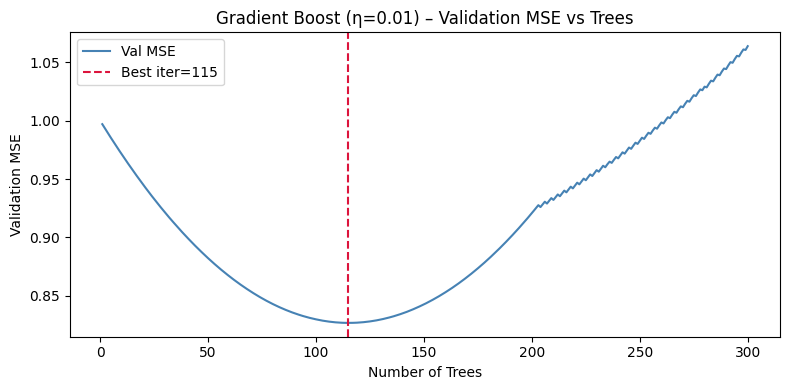

In [10]:
# step10 : plot default
plt.figure(figsize=(8, 4))
plt.plot(range(1, 301), val_mses, linewidth=1.5, color="steelblue",
         label="Val MSE")
plt.axvline(best_t+1, color="crimson", linestyle="--",
            label=f"Best iter={best_t+1}")
plt.xlabel("Number of Trees")
plt.ylabel("Validation MSE")
plt.title("Gradient Boost (η=0.01) – Validation MSE vs Trees")
plt.legend()
plt.tight_layout()
plt.savefig("q2_val_mse_eta001.png", dpi=150)
plt.show()



--- eta=0.001 ---
  eta=0.001 iter  50 | tr_mse=0.9869 val_mse=0.9853
  eta=0.001 iter 100 | tr_mse=0.9746 val_mse=0.9712
  eta=0.001 iter 150 | tr_mse=0.9628 val_mse=0.9578
  eta=0.001 iter 200 | tr_mse=0.9518 val_mse=0.9451
  eta=0.001 iter 250 | tr_mse=0.9414 val_mse=0.9330
  eta=0.001 iter 300 | tr_mse=0.9317 val_mse=0.9215
  best_iter=300 | tr_mse=0.9317 | val_mse=0.9215 | te_mse=0.9289

--- eta=0.01 ---
  eta=0.01 iter  50 | tr_mse=0.8994 val_mse=0.8823
  eta=0.01 iter 100 | tr_mse=0.8657 val_mse=0.8299
  eta=0.01 iter 150 | tr_mse=0.8987 val_mse=0.8427
  eta=0.01 iter 200 | tr_mse=0.9985 val_mse=0.9209
  eta=0.01 iter 250 | tr_mse=1.0630 val_mse=0.9828
  eta=0.01 iter 300 | tr_mse=1.1450 val_mse=1.0638
  best_iter=115 | tr_mse=0.8686 | val_mse=0.8269 | te_mse=0.8571

--- eta=0.1 ---
  eta=0.1 iter  50 | tr_mse=1.2830 val_mse=1.2032
  eta=0.1 iter 100 | tr_mse=1.2499 val_mse=1.1741
  eta=0.1 iter 150 | tr_mse=1.2637 val_mse=1.1816
  eta=0.1 iter 200 | tr_mse=1.2576 val_mse=1.172

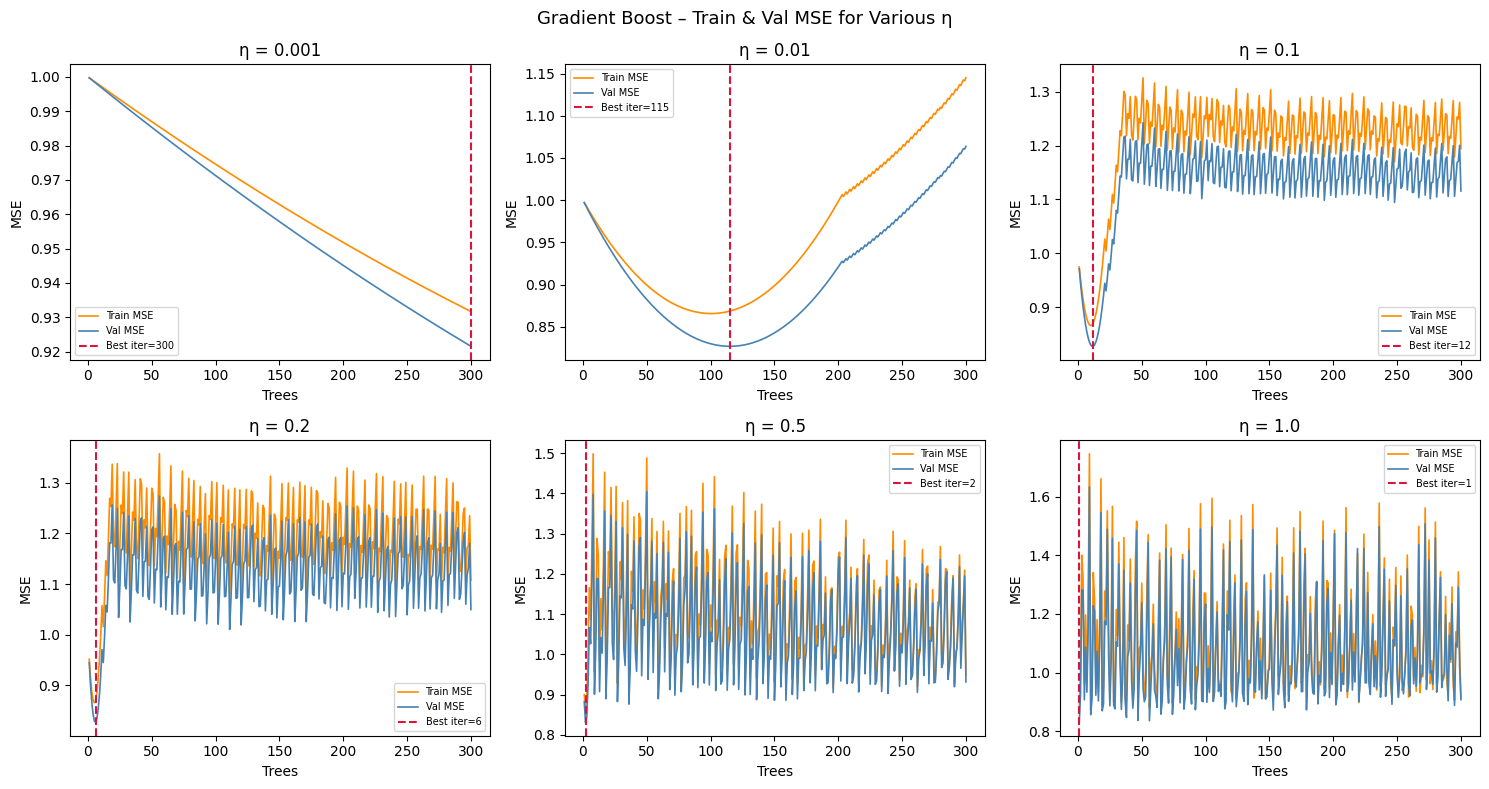

In [11]:

# step11 : sweep learning rates
etas = [0.001, 0.01, 0.1, 0.2, 0.5, 1.0]
results = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, eta in enumerate(etas):
    print(f"\n--- eta={eta} ---")
    tr_m, val_m, bt, te_m = gb_run(
        Xtr_p, ytr, Xval_p, yval, Xte_p, yte_f, eta=eta, T=300)
    results[eta] = dict(tr=tr_m, val=val_m, best_t=bt, te=te_m)
    print(f"  best_iter={bt+1} | tr_mse={tr_m[bt]:.4f} | "
          f"val_mse={val_m[bt]:.4f} | te_mse={te_m:.4f}")

    ax = axes[idx]
    ax.plot(range(1,301), tr_m,  linewidth=1.2, label="Train MSE",  color="darkorange")
    ax.plot(range(1,301), val_m, linewidth=1.2, label="Val MSE",   color="steelblue")
    ax.axvline(bt+1, color="crimson", linestyle="--",
               label=f"Best iter={bt+1}")
    ax.set_title(f"η = {eta}")
    ax.set_xlabel("Trees")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=7)

plt.suptitle("Gradient Boost – Train & Val MSE for Various η", fontsize=13)
plt.tight_layout()
plt.savefig("q2_eta_sweep.png", dpi=150)
plt.show()



In [12]:
# step12 : summary table
print("\n--- Summary Table ---")
print(f"{'eta':>8} {'best_t':>8} {'tr_mse':>10} {'val_mse':>10} {'te_mse':>10}")
for eta in etas:
    r  = results[eta]
    bt = r["best_t"]
    print(f"{eta:>8.3f} {bt+1:>8d} "
          f"{r['tr'][bt]:>10.4f} {r['val'][bt]:>10.4f} {r['te']:>10.4f}")


--- Summary Table ---
     eta   best_t     tr_mse    val_mse     te_mse
   0.001      300     0.9317     0.9215     0.9289
   0.010      115     0.8686     0.8269     0.8571
   0.100       12     0.8710     0.8273     0.8588
   0.200        6     0.8710     0.8274     0.8586
   0.500        2     0.8660     0.8311     0.8555
   1.000        1     0.8661     0.8311     0.8555
